# 05 Backtester

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path: sys.path.append(str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)
import pandas as pd, matplotlib.pyplot as plt
from src.features import load_latest_features
from src.strategy import MultiCryptoMomentumStrategy
from src.backtester import EventDrivenBacktester,compute_performance
from src.config import TRADE_DIR,REPORT_DIR
data=load_latest_features().sort_values(['Datetime','symbol']).reset_index(drop=True)
print(data.shape)

Project root: c:\Users\vidhi\Downloads\pro_crypto_trading_system\pro_crypto_trading_system
(2626935, 27)


In [2]:
# slice for smaller back test
unique_times=data['Datetime'].drop_duplicates().iloc[:20000]
bt_data=data[data['Datetime'].isin(unique_times)].copy()
print(bt_data.shape, bt_data['Datetime'].min(), bt_data['Datetime'].max())

(100000, 27) 2021-01-02 00:00:00+00:00 2021-03-12 13:20:00+00:00


In [3]:
strategy=MultiCryptoMomentumStrategy()
bt=EventDrivenBacktester(bt_data,strategy,initial_cash=100000)
equity_curve,trades=bt.run()
print(equity_curve.shape, trades.shape)
equity_curve.tail()

(20000, 4) (3662, 10)


,Datetime,equity,cash,gross_exposure
19995,2021-03-12 13:00:00+00:00,110114.763919,94269.934741,15844.829179
19996,2021-03-12 13:05:00+00:00,110000.703595,94269.934741,15730.768854
19997,2021-03-12 13:10:00+00:00,109987.029933,94269.934741,15717.095192
19998,2021-03-12 13:15:00+00:00,110072.444221,94269.934741,15802.509481
19999,2021-03-12 13:20:00+00:00,110004.560013,94269.934741,15734.625272


In [4]:
perf=compute_performance(equity_curve)
perf

{'total_return': np.float64(0.10026569452606848),
 'annualized_return': np.float64(0.6523849830027351),
 'annualized_volatility': np.float64(0.36251146234215126),
 'sharpe': np.float64(1.7996258071061788),
 'max_drawdown': -0.17206703002051915,
 'final_equity': np.float64(110004.56001271996)}

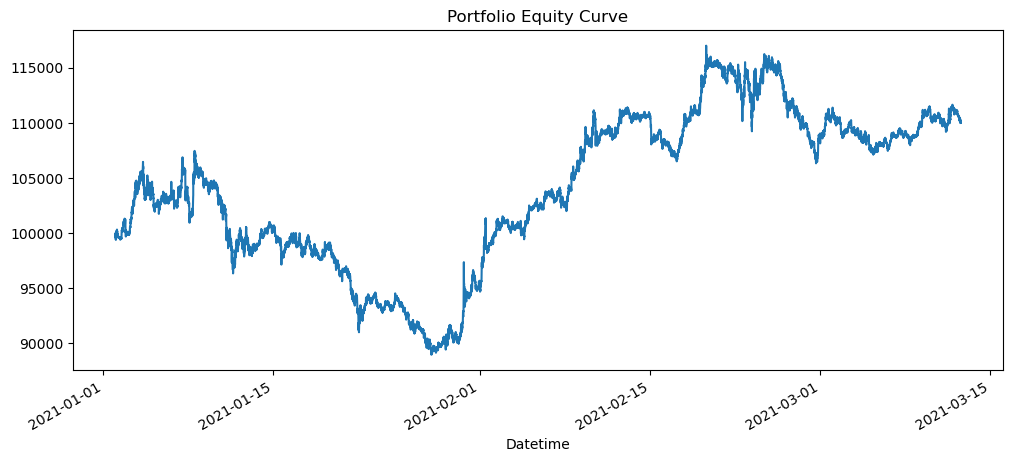

In [5]:
equity_curve.set_index('Datetime')['equity'].plot(figsize=(12,5),title='Portfolio Equity Curve')
plt.show()

In [6]:
trades.to_csv(TRADE_DIR/'crypto_trades.csv',index=False)
pd.DataFrame([perf]).to_csv(REPORT_DIR/'crypto_performance.csv',index=False)
print(TRADE_DIR/'crypto_trades.csv')
print(REPORT_DIR/'crypto_performance.csv')

C:\Users\vidhi\Downloads\pro_crypto_trading_system\pro_crypto_trading_system\outputs\trades\crypto_trades.csv
C:\Users\vidhi\Downloads\pro_crypto_trading_system\pro_crypto_trading_system\outputs\reports\crypto_performance.csv
